# Nernst Equation

The Nernst equation links an equilibrium electrode potential to the composition of the contacting phases. IUPAC writes it in terms of activities and notes that analytical chemistry often uses concentrations as a practical approximation {cite:p}`iupac_goldbook_nernst_2025`.

This example uses the Daniell cell:

$$
\mathrm{Zn(s) + Cu^{2+}(aq) \rightarrow Zn^{2+}(aq) + Cu(s)}
$$

For this reaction, $Q = [\mathrm{Zn}^{2+}]/[\mathrm{Cu}^{2+}]$ and $n = 2$. The model explored here is:

$$
E = E^\circ - \frac{RT}{nF}\ln Q
$$

```{admonition} What to modify
:class: dropdown
Change `T_values`, `[Cu2+]`, or `[Zn2+]` in the code cell. Notice that $Q=1$ gives $E=E^\circ$, and that the logarithmic correction becomes steeper as temperature increases.
```


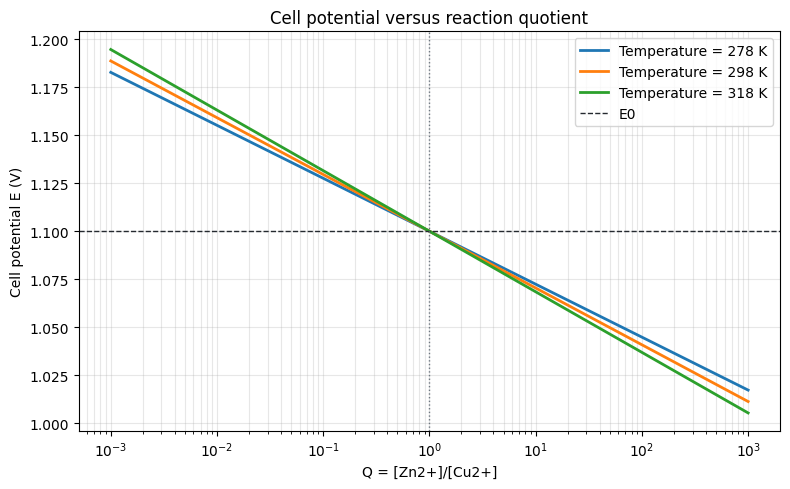

[Cu2+] = 0.010 M, [Zn2+] = 1.000 M, T = 298.15 K
Q = 100.0
E = 1.041 V


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Editable parameters
E0 = 1.10      # V, standard Daniell cell potential
n = 2
R = 8.314462618
F = 96485.33212
T_values = [278.15, 298.15, 318.15]
Q = np.logspace(-3, 3, 400)


def nernst(E0, T, n, Q):
    return E0 - (R * T) / (n * F) * np.log(Q)

plt.figure(figsize=(8, 5))
for T in T_values:
    plt.semilogx(Q, nernst(E0, T, n, Q), linewidth=2, label=f"Temperature = {T:.0f} K")
plt.axhline(E0, color="#24292f", linestyle="--", linewidth=1, label="E0")
plt.axvline(1, color="#6e7781", linestyle=":", linewidth=1)
plt.xlabel("Q = [Zn2+]/[Cu2+]")
plt.ylabel("Cell potential E (V)")
plt.title("Cell potential versus reaction quotient")
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

Cu2 = 0.010
Zn2 = 1.000
T = 298.15
Q_case = Zn2 / Cu2
E_case = nernst(E0, T, n, Q_case)
print(f"[Cu2+] = {Cu2:.3f} M, [Zn2+] = {Zn2:.3f} M, T = {T:.2f} K")
print(f"Q = {Q_case:.1f}")
print(f"E = {E_case:.3f} V")


## Interpretation

The computational figure shows that increasing $Q$ shifts the reaction further toward products and lowers the cell potential. The vertical line at $Q=1$ marks the simplified standard case; on both sides, the $\ln Q$ term corrects the value of $E^\circ$.

```{admonition} Check question
:class: dropdown
If $[\mathrm{Cu}^{2+}]$ decreases and $[\mathrm{Zn}^{2+}]$ increases, $Q$ increases. The equation then predicts a lower potential because the cell has less thermodynamic driving force left in the written direction.
```
